# ASSIGNMENT 10
# Comparing GAN and VAE Using Your Own Experimental Results

## Objective

The objective of this assignment is to compare a **GAN** and a **VAE** based on practical experimental results rather than only theoretical knowledge.

The comparison uses:

- **Assignment 4:** DCGAN trained on Fashion-MNIST
- **Assignment 8:** VAE trained on MNIST with a 2-dimensional latent space

Approximately 8 generated images from each model are compared using:

- Image sharpness
- Diversity
- Realism
- Training stability
- Ease of controlling the output
- Risk of mode collapse
- Typical applications

## Note About the Previous Experiments

Assignment 4 saved generated DCGAN images as 4 × 4 grids in the `dcgan_outputs` folder.

Assignment 8 trained a VAE for 20 epochs and decoded points across its 2D latent space, but it did not save a separate file containing eight random samples.

This notebook therefore:
1. Loads eight samples from the saved Assignment 4 GAN grid.
2. Recreates the same Assignment 8 VAE architecture and training configuration when needed, then generates eight samples from the learned latent prior.

## 1. Imports and Configuration

In [5]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cpu
Device: cpu


## 2. GAN Results from Assignment 4

Assignment 4 trained a DCGAN on Fashion-MNIST for 30 epochs and saved a 4 × 4 generated image grid every 5 epochs.

The final grid is expected at:

`dcgan_outputs/generated_epoch_30.png`

In [6]:
gan_grid_path = r"C:\Users\vishe\OneDrive\Documents\D_Drive\Notes\Sem_5\Gen_AI\gan outputs\dcgan_outputs\generated_epoch_30.png"

if not os.path.exists(gan_grid_path):
    candidates = []

    if os.path.exists("dcgan_outputs"):
        candidates = [
            os.path.join("dcgan_outputs", name)
            for name in os.listdir("dcgan_outputs")
            if name.startswith("generated_epoch_") and name.endswith(".png")
        ]

    if candidates:
        gan_grid_path = sorted(candidates)[-1]
        print("Using latest available GAN grid:", gan_grid_path)
    else:
        raise FileNotFoundError(
            "Assignment 4 GAN output was not found. "
            "Run Assignment 4 first so dcgan_outputs contains generated image grids."
        )

gan_grid = Image.open(gan_grid_path).convert("L")

print("GAN grid size:", gan_grid.size)
print("GAN grid file:", gan_grid_path)

GAN grid size: (122, 122)
GAN grid file: C:\Users\vishe\OneDrive\Documents\D_Drive\Notes\Sem_5\Gen_AI\gan outputs\dcgan_outputs\generated_epoch_30.png


## Select Eight GAN-Generated Images

Assignment 4 saved the generated grid with:

`nrow=4` and `padding=2`

The first eight individual samples are extracted from the final saved grid.

In [7]:
tile_size = 28
padding = 2

gan_samples = []

for index in range(8):
    row = index // 4
    col = index % 4

    left = padding + col * (tile_size + padding)
    top = padding + row * (tile_size + padding)
    right = left + tile_size
    bottom = top + tile_size

    sample = gan_grid.crop((left, top, right, bottom))
    gan_samples.append(np.array(sample, dtype=np.float32) / 255.0)

print("GAN samples selected:", len(gan_samples))

GAN samples selected: 8


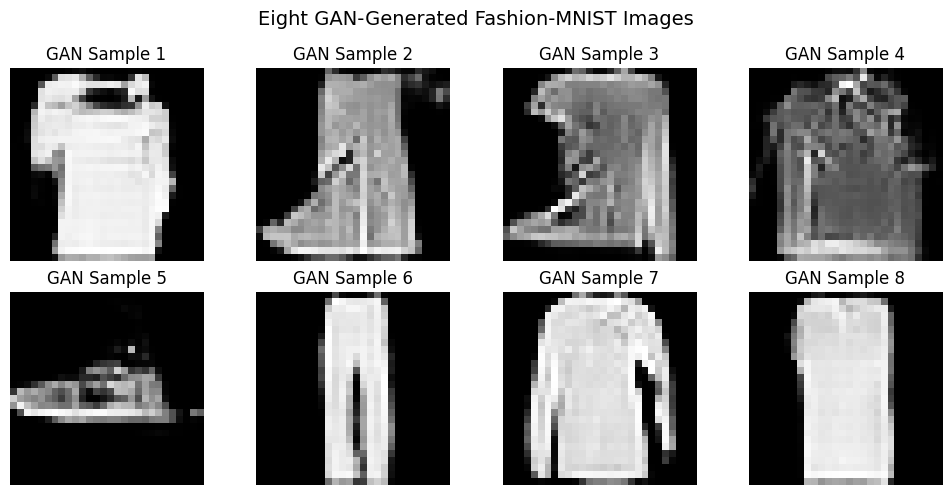

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, (ax, image) in enumerate(zip(axes.ravel(), gan_samples), start=1):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"GAN Sample {i}")
    ax.axis("off")

plt.suptitle("Eight GAN-Generated Fashion-MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

## 3. VAE Results from Assignment 8

Assignment 8 used:

- MNIST
- A 2-dimensional latent space
- Encoder producing `mu` and `logvar`
- Reparameterization
- Decoder
- Binary Cross-Entropy reconstruction loss
- KL-divergence loss
- Adam optimizer with learning rate `1e-3`
- 20 training epochs

The following implementation matches those settings.

In [9]:
transform = transforms.ToTensor()

vae_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

vae_loader = DataLoader(
    vae_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

print("VAE training samples:", len(vae_dataset))

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.49MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 124kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 954kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]

VAE training samples: 60000


In [10]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 256)
        self.fc3 = nn.Linear(256, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return torch.sigmoid(
            self.fc3(F.relu(self.fc2(z)))
        )

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


vae = VAE(2).to(device)
print(vae)

VAE(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=784, bias=True)
)


## VAE Training

The original Assignment 8 experiment trained for 20 epochs using Adam with learning rate `1e-3`.

The VAE objective combines reconstruction loss and KL divergence:

`Total Loss = Reconstruction Loss + KL Loss`

In [11]:
def vae_loss(reconstruction, x, mu, logvar):
    reconstruction_loss = F.binary_cross_entropy(
        reconstruction,
        x,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss + kl_loss


vae_optimizer = optim.Adam(
    vae.parameters(),
    lr=1e-3
)

vae_epochs = 20
vae_total_losses = []

for epoch in range(1, vae_epochs + 1):
    vae.train()
    total_loss = 0.0

    for images, _ in vae_loader:
        images = images.to(device).view(images.size(0), -1)

        vae_optimizer.zero_grad()

        reconstruction, mu, logvar = vae(images)
        loss = vae_loss(
            reconstruction,
            images,
            mu,
            logvar
        )

        loss.backward()
        vae_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(vae_loader.dataset)
    vae_total_losses.append(average_loss)

    print(
        f"Epoch {epoch:02d}/{vae_epochs} | "
        f"Total Loss: {average_loss:.4f}"
    )

Epoch 01/20 | Total Loss: 195.8808
Epoch 02/20 | Total Loss: 170.8431
Epoch 03/20 | Total Loss: 165.5106
Epoch 04/20 | Total Loss: 162.7108
Epoch 05/20 | Total Loss: 160.8562
Epoch 06/20 | Total Loss: 159.4741
Epoch 07/20 | Total Loss: 158.2925
Epoch 08/20 | Total Loss: 157.3939
Epoch 09/20 | Total Loss: 156.5451
Epoch 10/20 | Total Loss: 155.8971
Epoch 11/20 | Total Loss: 155.2395
Epoch 12/20 | Total Loss: 154.6670
Epoch 13/20 | Total Loss: 154.1534
Epoch 14/20 | Total Loss: 153.7519
Epoch 15/20 | Total Loss: 153.2848
Epoch 16/20 | Total Loss: 152.9156
Epoch 17/20 | Total Loss: 152.5526
Epoch 18/20 | Total Loss: 152.2401
Epoch 19/20 | Total Loss: 151.9652
Epoch 20/20 | Total Loss: 151.7068


In [12]:
# Generate eight VAE samples from the learned 2D latent prior

vae.eval()
torch.manual_seed(SEED)

z = torch.randn(8, 2, device=device)

with torch.no_grad():
    generated = vae.decode(z).cpu().numpy()

vae_samples = [
    image.reshape(28, 28)
    for image in generated
]

os.makedirs("assignment10_outputs", exist_ok=True)

for i, image in enumerate(vae_samples, start=1):
    plt.imsave(
        f"assignment10_outputs/vae_sample_{i}.png",
        image,
        cmap="gray"
    )

print("VAE samples generated:", len(vae_samples))

VAE samples generated: 8


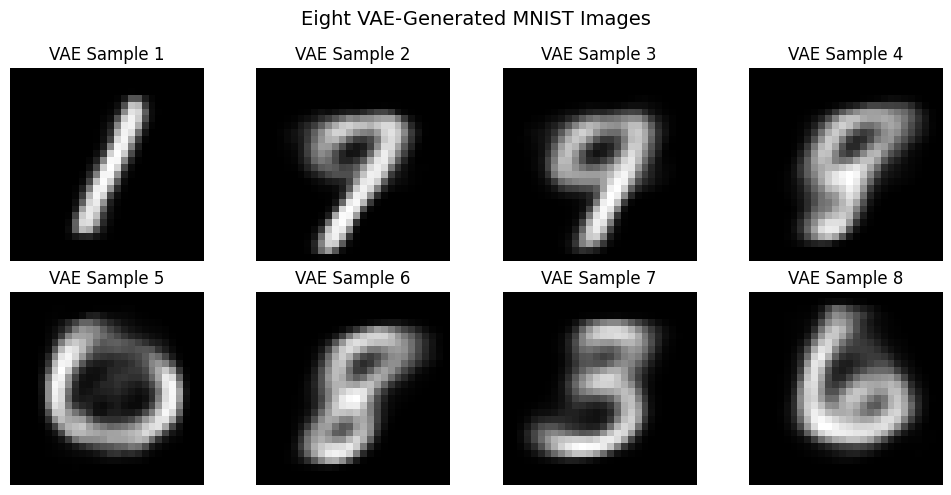

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, (ax, image) in enumerate(zip(axes.ravel(), vae_samples), start=1):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"VAE Sample {i}")
    ax.axis("off")

plt.suptitle("Eight VAE-Generated MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

# 4. Quantitative Comparison

Two simple image-level measurements are calculated.

### Sharpness
The variance of the Laplacian is used as a basic edge/sharpness indicator. Higher values generally indicate stronger local edges.

### Diversity
Average pairwise pixel difference is used as a simple diversity indicator. Higher values mean the selected samples differ more from each other.

These measurements support the visual inspection but do not completely measure realism.

In [14]:
# Sharpness without requiring OpenCV
from scipy.ndimage import laplace

def sharpness_score(image):
    return float(np.var(laplace(image)))

def diversity_score(images):
    flattened = np.array(images).reshape(len(images), -1)
    differences = []

    for i in range(len(flattened)):
        for j in range(i + 1, len(flattened)):
            differences.append(
                np.mean(np.abs(flattened[i] - flattened[j]))
            )

    return float(np.mean(differences))


gan_sharpness = np.mean([
    sharpness_score(image)
    for image in gan_samples
])

vae_sharpness = np.mean([
    sharpness_score(image)
    for image in vae_samples
])

gan_diversity = diversity_score(gan_samples)
vae_diversity = diversity_score(vae_samples)

metrics = pd.DataFrame({
    "Metric": [
        "Average Sharpness",
        "Average Diversity"
    ],
    "GAN": [
        gan_sharpness,
        gan_diversity
    ],
    "VAE": [
        vae_sharpness,
        vae_diversity
    ]
})

metrics

,Metric,GAN,VAE
0,Average Sharpness,0.167888,0.016346
1,Average Diversity,0.278524,0.122731


# 5. Comparison Table

The table summarizes the practical differences between the two models. Sharpness and diversity are supported by the measurements above; the remaining comparisons come from the training behavior and experimental setup used in Assignments 4 and 8.

In [15]:
comparison = pd.DataFrame({
    "Criterion": [
        "Image sharpness",
        "Diversity",
        "Realism",
        "Training stability",
        "Ease of controlling the output",
        "Risk of mode collapse",
        "Typical applications"
    ],
    "GAN (Assignment 4)": [
        "Generally sharper with stronger edges",
        "Can be high, but decreases if mode collapse occurs",
        "Usually more visually realistic and crisp",
        "Less stable because Generator and Discriminator compete",
        "Less directly interpretable; controlled through latent noise",
        "Higher",
        "Synthetic image generation, realistic sample generation, data augmentation"
    ],
    "VAE (Assignment 8)": [
        "Usually softer or blurrier",
        "Latent sampling encourages varied outputs",
        "Often less sharp but follows the learned data distribution",
        "More predictable optimization and easier-to-track loss",
        "Easier to inspect and control using the structured 2D latent space",
        "Lower",
        "Anomaly detection, representation learning, latent-space exploration, compression, image generation"
    ]
})

comparison

,Criterion,GAN (Assignment 4),VAE (Assignment 8)
0,Image sharpness,Generally sharper with stronger edges,Usually softer or blurrier
1,Diversity,"Can be high, but decreases if mode collapse oc...",Latent sampling encourages varied outputs
2,Realism,Usually more visually realistic and crisp,Often less sharp but follows the learned data ...
3,Training stability,Less stable because Generator and Discriminato...,More predictable optimization and easier-to-tr...
4,Ease of controlling the output,Less directly interpretable; controlled throug...,Easier to inspect and control using the struct...
5,Risk of mode collapse,Higher,Lower
6,Typical applications,"Synthetic image generation, realistic sample g...","Anomaly detection, representation learning, la..."


# 6. GAN vs VAE — Eight Samples Each

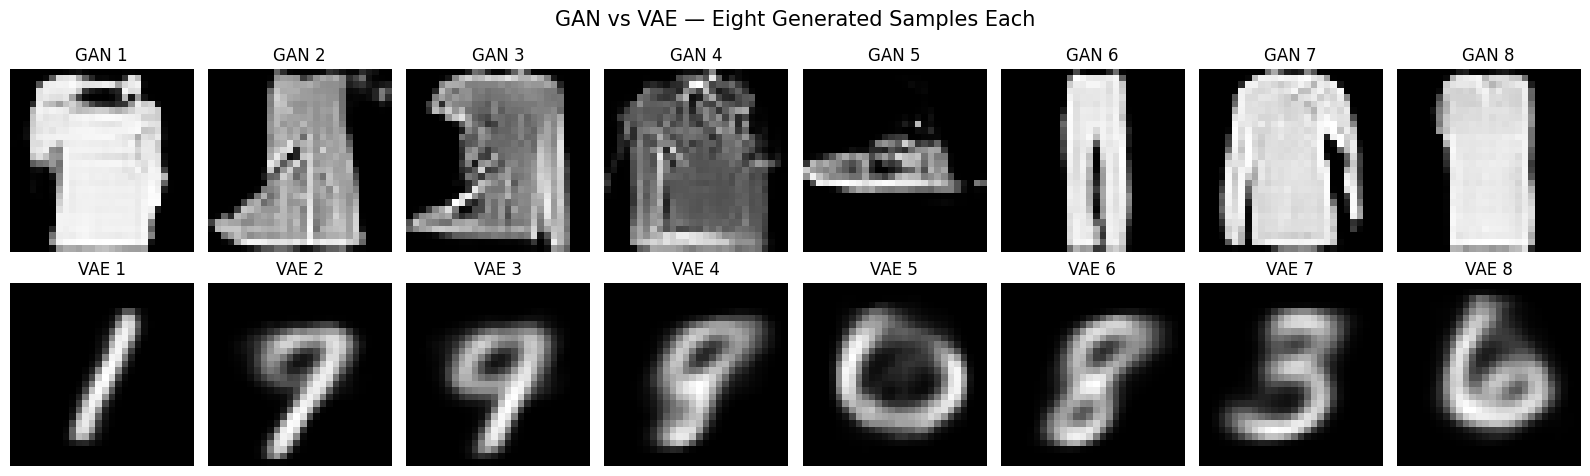

In [16]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

for i in range(8):
    axes[0, i].imshow(gan_samples[i], cmap="gray")
    axes[0, i].set_title(f"GAN {i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(vae_samples[i], cmap="gray")
    axes[1, i].set_title(f"VAE {i+1}")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("GAN", fontsize=12)
axes[1, 0].set_ylabel("VAE", fontsize=12)

plt.suptitle("GAN vs VAE — Eight Generated Samples Each", fontsize=15)
plt.tight_layout()
plt.show()

# 7. Training Stability

In Assignment 4, GAN training involves two competing networks, so Generator and Discriminator losses can oscillate rather than decrease smoothly.

In Assignment 8, the VAE minimizes a combined reconstruction and KL-divergence objective. This makes its training curve easier to interpret and generally more stable.

Therefore, for this criterion, the VAE has the advantage in training stability, while the GAN trades some stability for stronger adversarial generation quality.

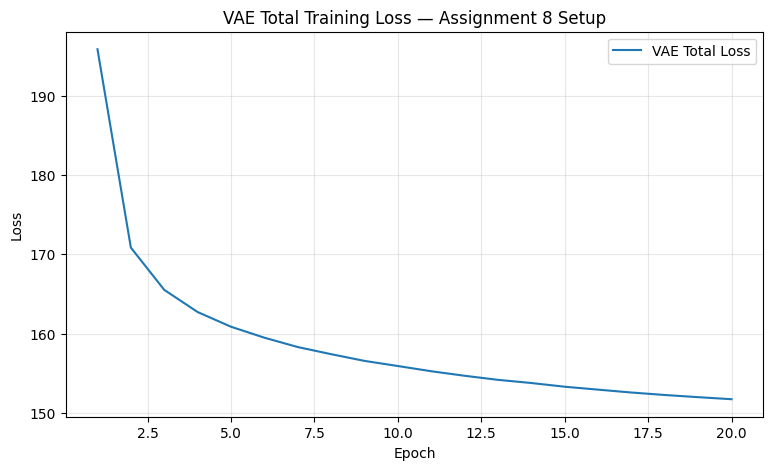

In [17]:
plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(vae_total_losses) + 1),
    vae_total_losses,
    label="VAE Total Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Total Training Loss — Assignment 8 Setup")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 8. Final Verdict

## 1. Which model would you prefer for generating synthetic training data?

**GAN**

I would prefer the GAN when the priority is sharp and realistic-looking synthetic images. The DCGAN is specifically trained to make generated samples resemble the training distribution, and its outputs are generally crisper than VAE outputs. The main limitation is that diversity must be monitored because mode collapse can reduce the usefulness of the synthetic dataset.

## 2. Which model would you prefer for anomaly detection?

**VAE**

I would prefer the VAE for anomaly detection because it learns a structured latent representation and reconstructs normal examples. Normal data should reconstruct with relatively low error, while unusual inputs can produce poorer reconstruction and therefore higher reconstruction error.

## 3. Why?

The practical trade-off is that the **GAN is stronger for high-quality synthetic image generation**, while the **VAE is easier to train and analyze through its structured latent space and reconstruction process**. Therefore, GAN is the better choice for synthetic training data when visual fidelity matters, while VAE is the better choice for anomaly detection.

# 9. Conclusion

The experiments demonstrate different strengths of GANs and VAEs.

The GAN learns through adversarial competition and can generate sharper, more realistic-looking samples, but the training is more sensitive and carries a greater risk of mode collapse.

The VAE learns a probabilistic latent space using reconstruction loss and KL divergence. Its outputs may be softer, but the structured latent representation makes the model easier to inspect and useful for reconstruction-based anomaly detection.

### Final Decision

| Task | Preferred Model |
|---|---|
| Synthetic training data | **GAN** |
| Anomaly detection | **VAE** |

The final judgement should be supported by the eight generated samples, the sharpness/diversity measurements, and the observed training behavior.